# Motion-Corrected Image Reconstruction (MCIR)


In [1]:
__version__ = '0.2.0'

# import engine module
import sirf.Gadgetron as pMR
from sirf.Utilities import examples_data_path
# from sirf_exercises import exercises_data_pathtoken
import sirf.Reg as pReg


from cil.framework import  AcquisitionGeometry, BlockDataContainer, BlockGeometry
from cil.optimisation.functions import Function, OperatorCompositionFunction, SmoothMixedL21Norm, L1Norm, L2NormSquared, BlockFunction, MixedL21Norm, IndicatorBox, TotalVariation, LeastSquares, ZeroFunction
from cil.optimisation.operators import GradientOperator, BlockOperator, ZeroOperator, CompositionOperator,LinearOperator
from cil.optimisation.algorithms import PDHG, FISTA, GD, SPDHG
from cil.plugins.ccpi_regularisation.functions import FGP_TV

# import further modules
import os
import numpy as np
import scipy.signal as sp_signal

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

import functools

import cil
import sirf

assert cil.version.version == '23.1.0'
assert sirf.__version__ == '3.5.0'

In [2]:
# Plotting function
data_path = '/home/jovyan/devel/SIRF-Contribs/src/notebooks/'
os.chdir(data_path)
import utils
from utils import plot_rpe_3d, plot_rpe_3d_simple
print ("Ciao")


Ciao


In [3]:
import importlib
importlib.reload(utils)
from utils import plot_rpe_3d, plot_rpe_3d_simple, saveCallback

In [4]:
############# SETUP #################
# number of motion states
Nms = 6
# max
max_shift = 20.
# setup linear shifts
shifts = np.linspace(0, 1, Nms) * max_shift

## Recon parameters
n_epochs = 100
# factor in front of L2Norm
omega = 0.5
# regularisation parameter
alpha = 2e-5

# data save directory
recons = 'recons_ignore-acq'


In [5]:
# data_path = exercises_data_path('MR')

filename = os.path.join(data_path, '3D_GRPE_no_motion.h5')

In [6]:
# Load in the data
acq_data = pMR.AcquisitionData(filename)
acq_data.sort_by_time()

reading from /home/jovyan/devel/SIRF-Contribs/src/notebooks/3D_GRPE_no_motion.h5 using ignore mask 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 

Started reading acquisitions from /home/jovyan/devel/SIRF-Contribs/src/notebooks/3D_GRPE_no_motion.h5
0%..10%..20%..31%..40%..50%..61%..70%..80%..90%..
Finished reading acquisitions from /home/jovyan/devel/SIRF-Contribs/src/notebooks/3D_GRPE_no_motion.h5


In [7]:
csm = pMR.CoilSensitivityData()
csm.smoothness = 100
csm.calculate(acq_data) 

E = pMR.AcquisitionModel(acqs=acq_data, imgs=csm)
E.set_coil_sensitivity_maps(csm)


/tmp/ipykernel_18146/199382526.py:2: ComplexWarning: Casting complex values to real discards the imaginary part
  show2D(csm.abs().as_array().astype('float32'))


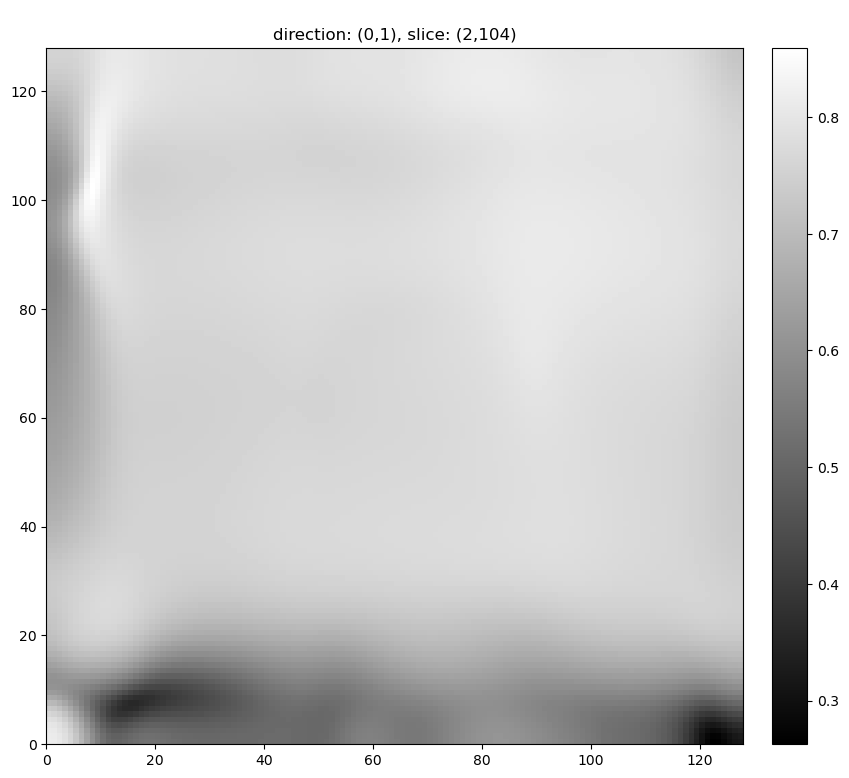

In [8]:
from cil.utilities.display import show2D
show2D(csm.abs().as_array().astype('float32'))

# Adding horizontal phase shift

In [9]:
# Get the information about the index of the phase encoding
pe_ky = acq_data.get_ISMRMRD_info('kspace_encode_step_1')

# Find the central value of each GRPE line (i.e. ky=0)
ky_idx = np.where(pe_ky == (np.max(pe_ky)+1)//2)

# Get the k-space as array
acq_data_arr = acq_data.as_array()

# Keep only points which have been acquired in the k-space centre (i.e. ky == 0 & kz == 0)
acq_data_arr = acq_data_arr[ky_idx[0], :, :]

# Select the last coil and the centre of each readout (i.e kx = 0) to get our final 1D motion signal
self_nav = np.abs(np.squeeze(acq_data_arr[:,3,acq_data_arr.shape[2]//2]))

# We said above that the value of the k-space centre should only vary because of motion. 
# This is not entirely true, because it can also vary because of other effects. One is that the spin system
# is in a transient steady state at the beginning of the data acquisition. 
# Therefore, we will simply overwrite the first entry in our motion signal
self_nav[0] = self_nav[1]

# Do some filtering
self_nav = sp_signal.medfilt(self_nav, 7)

# Interpolate self navigator to all phase encoding points
self_nav = np.interp(np.linspace(0, len(pe_ky)-1, len(pe_ky)), ky_idx[0], self_nav)

# Sort navigator and obtain index
nav_idx = np.argsort(self_nav)

# Bin data into Nms motion states each with the same amount of data
num_pe_per_ms = np.ceil(len(pe_ky) / Nms).astype(np.int64)
acq_idx_ms = []

for nnd in range(Nms):
    if nnd < Nms - 1:
        acq_idx_ms.append(nav_idx[nnd*num_pe_per_ms:(nnd+1)*num_pe_per_ms])
    else:
        acq_idx_ms.append(nav_idx[nnd*num_pe_per_ms:])

In [10]:
whole_data_array = acq_data.as_array()

## Create Motion States

In [11]:
def add_HORIZONTAL_phase_shift(acq_data, shift):
   ktraj = pMR.get_data_trajectory(acq_data)
   phase_factor = np.exp(1j*2*np.pi*ktraj[:,2]*shift)

   acq_data_new = acq_data.copy()
   acq_data_new.fill(acq_data.as_array()*phase_factor[:,None,None])
   return acq_data_new

In [17]:
# class LinearOperatorWithNormCache():
        
#     def norm(self):
#         if self._norm is not None:
#             return self._norm
#         self._norm = self.calculate_norm()
#         return self._norm

#     def calculate_norm(self):
#         return pMR.AcquisitionModel.norm(self)



class MRAcquisitionModelWithNormCache(pMR.AcquisitionModel):

    def __init__(self, acqs, imgs):
        
        self._norm = None
        super().__init__(acqs, imgs)

    def norm(self):
        if self._norm is not None:
            return self._norm
        self._norm = self.calculate_norm()
        return self._norm

    def calculate_norm(self):
        return pMR.AcquisitionModel.norm(self)
        



In [18]:

# Go through each motion states, create corresponding k-space and acquisition model

acq_ms = [0] * Nms
E_ms = [0] * Nms

first_dim = acq_data.dimensions()[0]
indeces_to_split = np.linspace(0, first_dim, Nms+1).astype(int)
whole_data_array = acq_data.as_array()

for ind in range(Nms):
    
    # indeces should be selected randomly    
    indeces_to_select = np.arange(indeces_to_split[ind], indeces_to_split[ind+1], 1)
    part_of_data = acq_data.get_subset(indeces_to_select)
    
    data_with_shift = add_HORIZONTAL_phase_shift(part_of_data, shifts[ind])
    
    acq_ms[ind] = data_with_shift      
    acq_ms[ind].sort_by_time()
        
    # Create acquisition model
    E_tmp = pMR.AcquisitionModel(acqs=acq_ms[ind], imgs=csm)
    E_tmp.set_coil_sensitivity_maps(csm)
    im_ms = E_tmp.inverse(acq_ms[ind])

    # E_ms[ind] = pMR.AcquisitionModel(acqs=acq_ms[ind], imgs=im_ms)
    # E_ms[ind]._norm = None
    E_ms[ind] = MRAcquisitionModelWithNormCache(acqs=acq_ms[ind], imgs=im_ms)
    E_ms[ind].set_coil_sensitivity_maps(csm)

In [19]:
print (E_ms[-1].norm())

15.723179817199707


In [20]:
print (E_ms[-1].norm())

15.723179817199707


In [29]:
import functools
im_fista_ms = [0] * Nms

for ind in range(Nms):

    # Starting image
    x_init = im_ms.clone()
    x_init.fill(0.0)

    # Objective function
    f = LeastSquares(E_ms[ind], acq_ms[ind], c=1)
    G = ZeroFunction()

    # Set up FISTA for least squares
    fista = FISTA(initial=x_init, f=f, g=G)
    fista.max_iteration = 100
    fista.update_objective_interval = 5

    # Run FISTA
    sc = functools.partial(saveCallback, fista, f"FISTA_L2_ms_{ind}", os.path.join(data_path, recons, f'MS_{Nms}'))
    fista.run(10, verbose=1, callback=sc)
    
    # Get result
    im_fista_ms[ind] = fista.get_output()

     Iter   Max Iter     Time/Iter            Objective
                               [s]                     
        0        100         0.000          5.55129e-03
        5        100        13.817          3.47758e-04
       10        100        13.781          4.56266e-05
-------------------------------------------------------
       10        100        13.781          4.56266e-05
Stop criterion has been reached.

     Iter   Max Iter     Time/Iter            Objective
                               [s]                     
        0        100         0.000          5.70587e-03
        5        100        13.967          3.33001e-04
       10        100        14.181          5.96551e-05
-------------------------------------------------------
       10        100        14.181          5.96551e-05
Stop criterion has been reached.

     Iter   Max Iter     Time/Iter            Objective
                               [s]                     
        0        100         0.000  

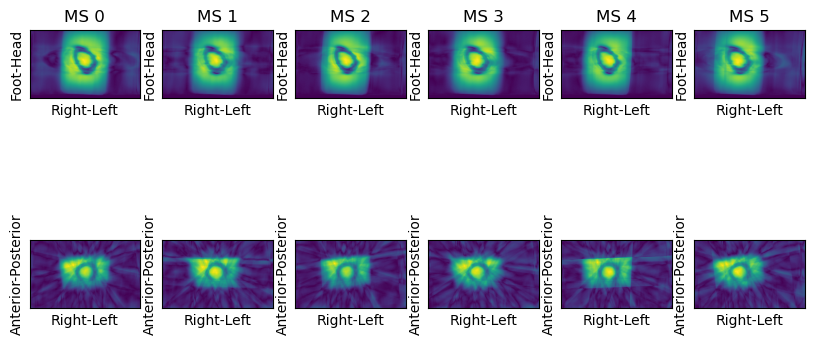

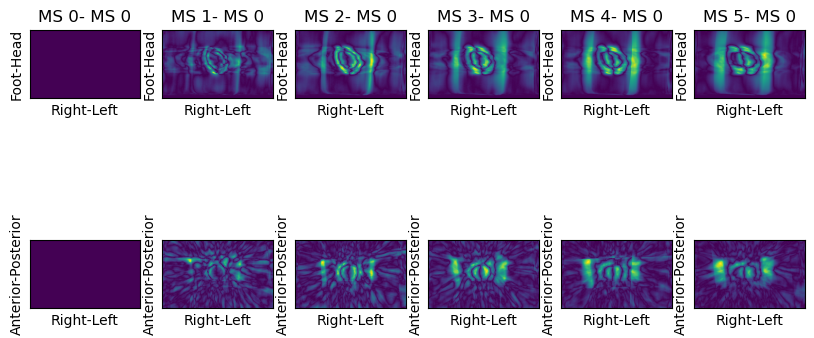

In [30]:
# Prepare results
#%matplotlib inline
im_fista_ms_arr = []
im_fista_diff_arr = []
for ind in range(Nms):
    im_fista_ms_arr.append(im_fista_ms[ind].as_array())
    im_fista_diff_arr.append(np.abs(im_fista_ms[ind].as_array()) - np.abs(im_fista_ms_arr[0]))
    
# Visualise different motion states
plot_rpe_3d_simple(im_fista_ms_arr[:], [64, 64], [ f'MS {ms}' for ms in range(Nms) ])
print('\n')
# Visualise difference to first motion state
plot_rpe_3d_simple(im_fista_diff_arr[:], [64, 64], [f'MS {ms}- MS 0'  for ms in range(Nms) ])

## Estimate Motion Vector fields

In [31]:
im_fista_ms_abs = []
for ind in range(Nms):
    im_fista_ms_abs.append(im_fista_ms[ind].abs())

In [32]:
class NiftyResampleWithNormCache(pReg.NiftyResample):

    def __init__(self, *args, **kwargs):
        self._norm = None
        super().__init__(*args, **kwargs)
        
    def norm(self):
        if self._norm is not None:
            return self._norm
        self._norm = self.calculate_norm()
        return self._norm

    def calculate_norm(self):
        return LinearOperator.PowerMethod(self, method='composed_with_adjoint')

In [33]:
# Motion fransformation object
mf_resampler = [0] * Nms

# Forward transformation (i.e. reference image transformed to current motion state)
im_forward = [0] * Nms

# Backward transformation (i.e. current motion image transformed to reference motion state)
im_backward = [0] * Nms

tms = []

for shift in shifts:
    t_x=shift
    t_y=0
    tm = pReg.AffineTransformation(np.array(\
            [[1, 0, 0, t_x], \
             [0, 1, 0, t_y], \
             [0, 0, 1, 0  ], \
             [0, 0, 0, 1  ]]))
    tms.append(tm)
    
for ind in range(Nms):

    # Create resampler
    # mf_resampler[ind] = pReg.NiftyResample()
    mf_resampler[ind] = NiftyResampleWithNormCache()
    mf_resampler[ind].set_reference_image(im_fista_ms[0])
    mf_resampler[ind].set_floating_image(im_fista_ms[ind])
    mf_resampler[ind].add_transformation(tms[ind])
    mf_resampler[ind].set_padding_value(0)
    mf_resampler[ind].set_interpolation_type_to_linear()

    im_forward[ind] = mf_resampler[ind].forward(im_fista_ms[0])
    im_backward[ind] = mf_resampler[ind].backward(im_fista_ms[ind])

In [34]:
mf_resampler[0].norm()

0.9999994635580531

In [41]:
mf_resampler[0].norm()

0.9999994635580531

## Let's look at the backward transformed images (i.e. the images transformed to the reference motion state).

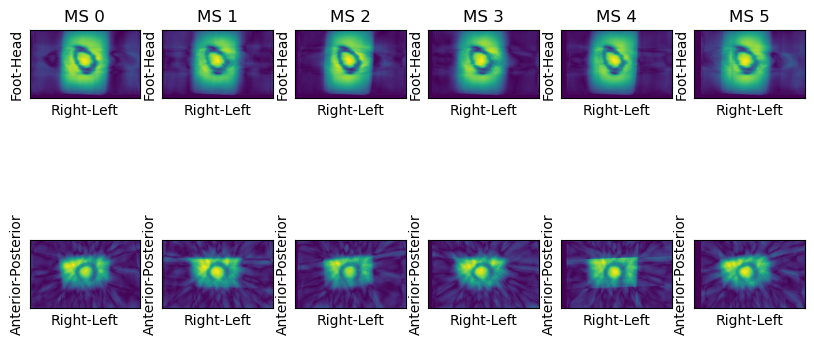

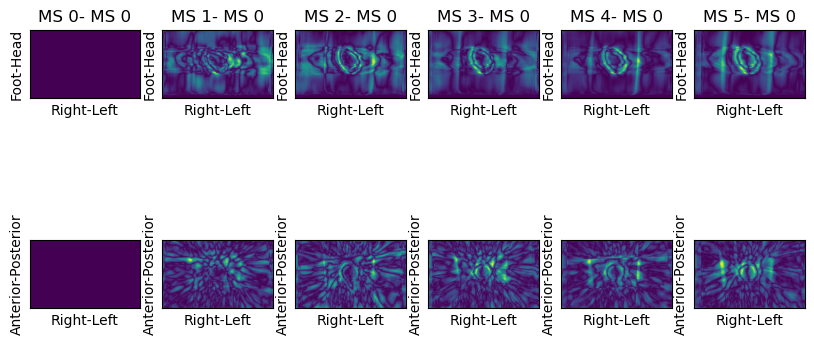

In [42]:
# Prepare results
%matplotlib inline
im_backward_arr = []
im_backward_diff_arr = []
for ind in range(Nms):
    im_backward_arr.append(im_backward[ind].as_array())
    im_backward_diff_arr.append(np.abs(im_backward[ind].as_array()) - np.abs(im_backward[0].as_array()))
    
# Visualise different motion states transformed to reference motion state
plot_rpe_3d_simple(im_backward_arr, [64, 64], [ f'MS {ms}' for ms in range(Nms) ])

# Visualise difference to first motion state
plot_rpe_3d_simple(im_backward_diff_arr, [64, 64], [f'MS {ms}- MS 0'  for ms in range(Nms) ])


In [43]:
n1 = mf_resampler[0].norm()
print (n1)

0.9999994635580531


In [44]:
n2 = E_ms[0].norm()

In [45]:
C = [CompositionOperator(am, res) for am, res in zip(*(E_ms, mf_resampler))]
A = BlockOperator(*C)


In [46]:
n3 = C[0].norm()

In [47]:
print (f"C norm: {n3}, E_ms norm: {n2}, mf_resampler norm: {n1}, prod: {n1 * n2}")

C norm: 16.152516283228188, E_ms norm: 16.152524948120117, mf_resampler norm: 0.9999994635580531, prod: 16.152516283228188


## Modifications to CIL/SIRF (check comments to see whether cell(s) can be removed)

In [50]:
from pReg import NiftyResampler 
from cil.optimisation.operators import LinearOperator
from packaging import version as pversion

In [51]:
# this cell is to be removed if using newer CIL version that implements 1472

if pversion.parse(cil.version.version) < pversion.parse('23.1.0'):
    def CompositionOperator_norm(comp_operator):
        out = 1.
        for factor in comp_operator.operators:
            out = out * factor.norm()
        return out

    setattr(CompositionOperator, 'norm', CompositionOperator_norm)

In [52]:
# this cell is to be removed if using newer CIL version that implements 1479


import types   # import needed for later
if pversion.parse(cil.version.version) < pversion.parse('23.1.0'):
    # Overriding proximal, to remove call to function "check_input"
    def new_proximal(self, x, tau, out=None):
        arr = x.as_array()
        if np.iscomplexobj(arr):
            # do real and imag part indep
            in_arr = np.asarray(arr.real, dtype=np.float32, order='C')
            res, info = self.proximal_numpy(in_arr, tau)
            arr.real = res[:]
            in_arr = np.asarray(arr.imag, dtype=np.float32, order='C')
            res, info = self.proximal_numpy(in_arr, tau)
            arr.imag = res[:]
            self.info = info
            if out is not None:
                out.fill(arr)
            else:
                out = x.copy()
                out.fill(arr)
                return out
        else:
            arr = np.asarray(x.as_array(), dtype=np.float32, order='C')
            res, info = self.proximal_numpy(arr, tau)
            self.info = info
            if out is not None:
                out.fill(res)
            else:
                out = x.copy()
                out.fill(res)
                return out

## MCIR with PDHG

In [53]:
from datetime import datetime

In [54]:
C = [CompositionOperator(am, res) for am, res in zip(*(E_ms, mf_resampler))]
A = BlockOperator(*C)

acq_ms_block = BlockDataContainer(*acq_ms)
x_init = A.adjoint(acq_ms_block)
x_init.fill(0.0)

F_all_subs = []
for i in acq_ms:
    F_all_subs.append(omega*L2NormSquared(b=i))
    
F = BlockFunction(*F_all_subs)

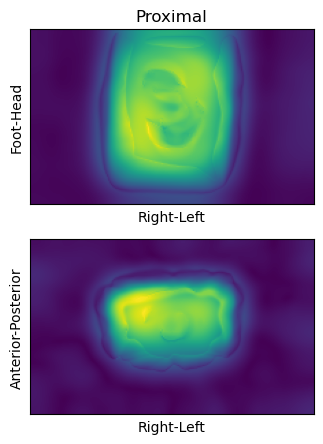

In [55]:
G = alpha * FGP_TV(device='cpu', nonnegativity=False)

if pversion.parse(cil.version.version) < pversion.parse('23.1.0'):
    # this line is to be removed if using newer CIL version that implements 1479
    G.proximal = types.MethodType(new_proximal, G)
    print("proximal updated")

nn = G.proximal(im_fista_ms[0], tau=1.0)
plot_rpe_3d_simple([nn.as_array()], [64, 64], ['Proximal'])


In [56]:
aa = A[0]
aa.norm()

16.152516283228188

In [67]:


pdhg_2 = PDHG(
            f=F, g=G, operator=A,
            max_iteration=n_epochs,
            update_objective_interval=1)


In [68]:
sc = functools.partial(saveCallback, pdhg_2, f"PDHG_TV_{Nms:02d}ms", os.path.join(data_path, recons, f'MS_{Nms}'))
    
start = datetime.now()
pdhg_2.run(10, verbose=2, callback=sc)

pdhg_2.update_objective_interval = 5
pdhg_2.run(5, verbose=2, callback=sc)

pdhg_2.update_objective_interval = 10
pdhg_2.run(verbose=2, callback=sc)
end = datetime.now()

pdhg_2_time = end-start

     Iter   Max Iter     Time/Iter        Primal          Dual     Primal-Dual
                               [s]     Objective     Objective             Gap
        0        100         0.000    1.69328e-02  -0.00000e+00    1.69328e-02
        1        100        91.004    5.88343e-03 8.26674e-04+3.64969e-13j5.05676e-03-3.64969e-13j
        2        100        92.543    3.50000e-03 7.05105e-04-3.40912e-07j2.79489e-03+3.40912e-07j
        3        100        93.068    1.75038e-03 7.63183e-04-5.36163e-07j9.87196e-04+5.36163e-07j
        4        100        93.157    1.02500e-03 8.04394e-04+3.24377e-07j2.20609e-04-3.24377e-07j
        5        100        93.426    1.10907e-03 7.59386e-04+1.06950e-06j3.49684e-04-1.06950e-06j
        6        100        93.413    1.49902e-03 6.52606e-04+1.27694e-06j8.46409e-04-1.27694e-06j


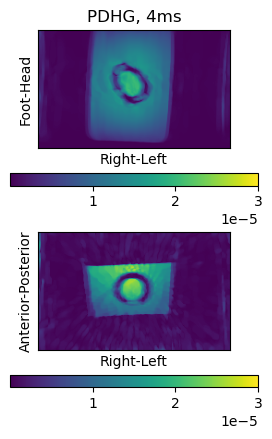

In [59]:
im = pdhg_2.get_output().as_array()

%matplotlib inline
plot_rpe_3d([im],
            [59, 64],
            [f'PDHG, {Nms}ms'],
            [3*10**(-5)],
            f'PDHG, {Nms}ms.png')

## MCIR with SPDHG

In [60]:
# reuse the same TV instance
# G = alpha * FGP_TV(device='cpu', nonnegativity=False)
# G.proximal = types.MethodType(new_proximal, G)

start = datetime.now()
spdhg_2 = SPDHG(
            f = F, g = G, operator = A, 
            max_iteration = n_epochs*Nms, 
            update_objective_interval = Nms)
  

In [61]:
sc = functools.partial(saveCallback, pdhg_2, f"SPDHG_TV_{Nms:02d}ms", os.path.join(data_path, recons, f'MS_{Nms}'))
    
start = datetime.now()
spdhg_2.run(10 * Nms, verbose=2, callback=sc)

spdhg_2.update_objective_interval = 5 * Nms
spdhg_2.run(5 * Nms, verbose=2, callback=sc)

spdhg_2.update_objective_interval = 10 * Nms
spdhg_2.run(verbose=2, callback=sc)

end = datetime.now()

spdhg_2_time = end-start

     Iter   Max Iter     Time/Iter        Primal          Dual     Primal-Dual
                               [s]     Objective     Objective             Gap
        0        600         0.000    1.69328e-02  -0.00000e+00    1.69328e-02
        6        600        18.767    1.47884e-03 6.43688e-04-1.26078e-05j8.35156e-04+1.26078e-05j
       12        600        19.132    1.08981e-03 6.16256e-04-5.76724e-06j4.73556e-04+5.76724e-06j
       18        600        19.155    1.22664e-03 4.69539e-04-2.39763e-05j7.57105e-04+2.39763e-05j
       24        600        19.160    1.15926e-03 3.30176e-04-1.80208e-05j8.29089e-04+1.80208e-05j
       30        600        19.133    8.34499e-04 2.77558e-04+2.03581e-05j5.56942e-04-2.03581e-05j
       36        600        19.146    7.03963e-04 2.46424e-04+6.73252e-06j4.57539e-04-6.73252e-06j
       42        600        19.142    6.58820e-04 2.88287e-04-3.16350e-06j3.70533e-04+3.16350e-06j
       48        600        19.130    6.26912e-04 3.23906e-04+1.38668e

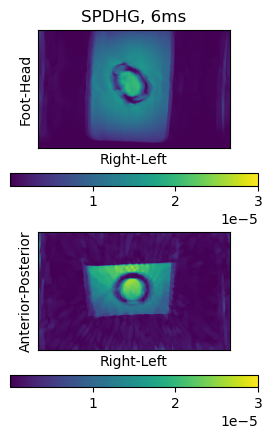

In [62]:
im = spdhg_2.get_output().as_array()

%matplotlib inline
plot_rpe_3d([im],
            [59, 64],
            [f'SPDHG, {Nms}ms'],
            [3*10**(-5)],
            f'SPDHG, {Nms}ms.png')

In [63]:
pdhg_2_time.seconds/3600

2.968888888888889

In [64]:
spdhg_2_time.seconds/3600

3.762777777777778

In [65]:
np.save(os.path.join(data_path, recons, f'MS_{Nms}', 'PDHG_objective.npy'), np.asarray(pdhg_2.objective))

In [66]:
np.save(os.path.join(data_path, recons, f'MS_{Nms}', 'SPDHG_objective.npy'), np.asarray(spdhg_2.objective))